In [36]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#import cartopy.crs as ccrs
from cartopy import crs as ccrs, feature as cfeature
import netCDF4
from netCDF4 import Dataset
from datetime import datetime as dt

import warnings
warnings.filterwarnings('ignore')

# conversion factor for K to deg C for plotting
KtoC = -273.15

# Load one year of CanESM data (1961)

In [3]:
file_path = '../../../Data/CMIP6/CanESM5/tas_day_CanESM5_historical_r1i1p1f1_gn_19610101-19611231.nc'

# open without dask chunking and see if it crashes
#ds = xr.open_mfdataset(file_path) #, chunks={'time': 10})

# can't do quantile calc unless we are chunked
ds = xr.open_mfdataset(file_path)#, chunks={'latitude': 10, 'longitude': 10})

In [4]:
ds

<xarray.Dataset> Size: 12MB
Dimensions:    (time: 365, bnds: 2, lat: 64, lon: 128)
Coordinates:
  * time       (time) object 3kB 1961-01-01 12:00:00 ... 1961-12-31 12:00:00
  * lat        (lat) float64 512B -87.86 -85.1 -82.31 ... 82.31 85.1 87.86
  * lon        (lon) float64 1kB 0.0 2.812 5.625 8.438 ... 351.6 354.4 357.2
    height     float64 8B ...
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object 6kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    lat_bnds   (lat, bnds) float64 1kB dask.array<chunksize=(64, 2), meta=np.ndarray>
    lon_bnds   (lon, bnds) float64 2kB dask.array<chunksize=(128, 2), meta=np.ndarray>
    tas        (time, lat, lon) float32 12MB dask.array<chunksize=(1, 64, 128), meta=np.ndarray>
Attributes: (12/53)
    CCCma_model_hash:            3dedf95315d603326fde4f5340dc0519d80d10c0
    CCCma_parent_runid:          rc3-pictrl
    CCCma_pycmor_hash:           33c30511acc319a98240633965a04ca99c26427e
    CCCma_runid:                 rc3.1-his01
    Conventions:                 CF-1.7 CMIP-6.2
    YMDH_branch_time_in_child:   1850:01:01:00
    ...                          ...
    tracking_id:                 hdl:21.14100/dc83adf2-3502-4f41-8c9b-80e6bf0...
    variable_id:                 tas
    variant_label:               r1i1p1f1
    version:                     v20190429
    license:                     CMIP6 model data produced by The Government ...
    cmor_version:                3.4.0

## convert time variable

In [12]:
ds['time'] = ds.indexes['time'].to_datetimeindex()

/var/folders/ml/p381h5fs0x9g7g5ksj8fh6qh0000gn/T/ipykernel_19491/2135622427.py:1: FutureWarning: In a future version of xarray to_datetimeindex will default to returning a 'us'-resolution DatetimeIndex instead of a 'ns'-resolution DatetimeIndex. This warning can be silenced by explicitly passing the `time_unit` keyword argument.
  ds['time'] = ds.indexes['time'].to_datetimeindex()
/var/folders/ml/p381h5fs0x9g7g5ksj8fh6qh0000gn/T/ipykernel_19491/2135622427.py:1: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  ds['time'] = ds.indexes['time'].to_datetimeindex()


In [13]:
ds.time

<xarray.DataArray 'time' (time: 365)> Size: 3kB
array(['1961-01-01T12:00:00.000000000', '1961-01-02T12:00:00.000000000',
       '1961-01-03T12:00:00.000000000', ..., '1961-12-29T12:00:00.000000000',
       '1961-12-30T12:00:00.000000000', '1961-12-31T12:00:00.000000000'],
      shape=(365,), dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 3kB 1961-01-01T12:00:00 ... 1961-12-31T12:...
    height   float64 8B ...

In [14]:
weights = np.cos(np.deg2rad(ds.lat))
weights.name = "weights" # not sure why we did this since we aren't merging with the dataset but OK

# get weighted spatial mean
ds_t2m_ts = ds.tas.weighted(weights).mean(["lon","lat"])
ds_t2m_ts 

<xarray.DataArray 'tas' (time: 365)> Size: 3kB
dask.array<truediv, shape=(365,), dtype=float64, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 3kB 1961-01-01T12:00:00 ... 1961-12-31T12:...
    height   float64 8B 2.0

Text(0.5, 1.0, '')

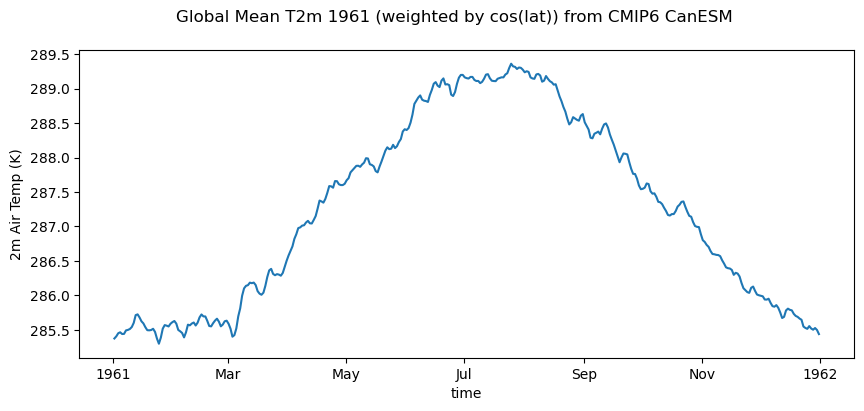

In [15]:
# plot the time series
fig,ax = plt.subplots(1,1, figsize=(10,4))
ds_t2m_ts.plot()
ax.set_ylabel("2m Air Temp (K)")
#ax.xaxis.set_tick_params(rotation=45)
plt.suptitle("Global Mean T2m 1961 (weighted by cos(lat)) from CMIP6 CanESM")
plt.title("")

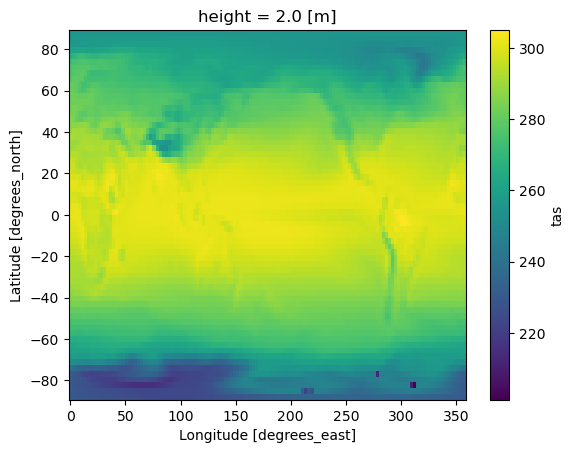

In [29]:
# map of annual temp by grid cell
ds.tas.mean(["time"]).plot()

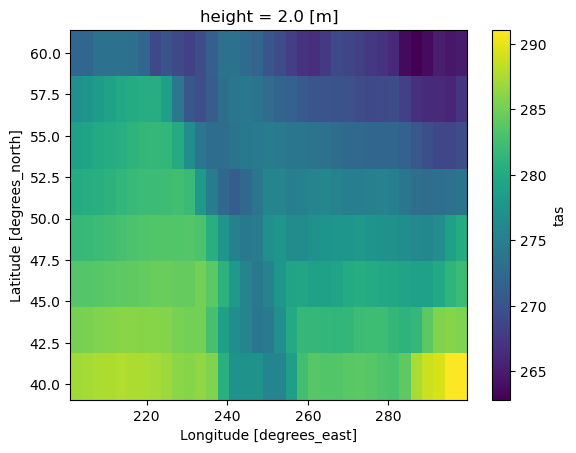

In [30]:
ds.tas.sel(lat=slice(40,60), lon=slice(200,300)).mean(["time"]).plot()

Text(0.5, 1.0, '\nMean Temp 1961 from CanESM Hist')

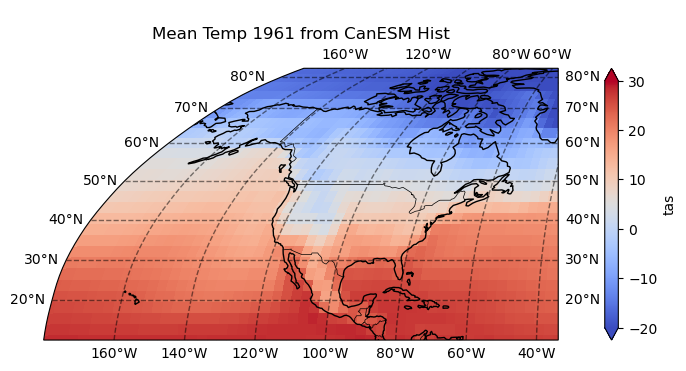

In [38]:
# create blank fig
fig = plt.figure(figsize = (12,12))

# Baseline
ax1 = fig.add_subplot(3,1,1,projection=ccrs.Robinson(central_longitude=0))

# add coastlines and grid
ax1.coastlines()
ax1.gridlines(draw_labels=True, linewidth=1, color='black', alpha=0.5, linestyle='--')

# plot data and exclude tropics
(ds.tas.mean(["time"])+KtoC).plot(
    ax=ax1,
    transform=ccrs.PlateCarree(), 
    vmin=-20,
    vmax=30, 
    cmap="coolwarm"#"YlOrRd"#cmap="coolwarm"
)

ax1.set_extent((-180, -50, 10, 75))
ax1.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='black')
ax1.set_title("\nMean Temp 1961 from CanESM Hist")

### compute 75th percentile values for each grid cell

In [16]:
# load it into memory because I can't do quantile on on the dask dataset (also can't figure out how to do percentile)
ds.load()

<xarray.Dataset> Size: 12MB
Dimensions:    (time: 365, bnds: 2, lat: 64, lon: 128)
Coordinates:
  * time       (time) datetime64[ns] 3kB 1961-01-01T12:00:00 ... 1961-12-31T1...
  * lat        (lat) float64 512B -87.86 -85.1 -82.31 ... 82.31 85.1 87.86
  * lon        (lon) float64 1kB 0.0 2.812 5.625 8.438 ... 351.6 354.4 357.2
    height     float64 8B 2.0
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object 6kB 1961-01-01 00:00:00 ... 1962-01-01 00:...
    lat_bnds   (lat, bnds) float64 1kB -90.0 -86.58 -86.58 ... 86.58 86.58 90.0
    lon_bnds   (lon, bnds) float64 2kB -1.406 1.406 1.406 ... 355.8 355.8 358.6
    tas        (time, lat, lon) float32 12MB 248.5 248.3 248.1 ... 238.7 238.6
Attributes: (12/53)
    CCCma_model_hash:            3dedf95315d603326fde4f5340dc0519d80d10c0
    CCCma_parent_runid:          rc3-pictrl
    CCCma_pycmor_hash:           33c30511acc319a98240633965a04ca99c26427e
    CCCma_runid:                 rc3.1-his01
    Conventions:                 CF-1.7 CMIP-6.2
    YMDH_branch_time_in_child:   1850:01:01:00
    ...                          ...
    tracking_id:                 hdl:21.14100/dc83adf2-3502-4f41-8c9b-80e6bf0...
    variable_id:                 tas
    variant_label:               r1i1p1f1
    version:                     v20190429
    license:                     CMIP6 model data produced by The Government ...
    cmor_version:                3.4.0

In [385]:
#ds.t2m

In [18]:
%%time
#c_75 = ds.t2m.where(ds.t2m != 0).quantile(0.75, dim=('time'))
c_75 = ds.tas.quantile(0.75, dim=('time'))
c_75

CPU times: user 214 ms, sys: 10.6 ms, total: 225 ms
Wall time: 225 ms


<xarray.DataArray 'tas' (lat: 64, lon: 128)> Size: 66kB
array([[240.04521179, 239.72415161, 239.36999512, ..., 240.77711487,
        240.42233276, 240.17442322],
       [240.74336243, 240.13876343, 239.34466553, ..., 242.83950806,
        242.19338989, 241.4538269 ],
       [240.55351257, 239.97833252, 239.15718079, ..., 243.55804443,
        242.57266235, 241.53024292],
       ...,
       [270.95523071, 271.02883911, 271.00741577, ..., 269.8414917 ,
        270.37261963, 270.92495728],
       [270.88656616, 271.09631348, 271.10894775, ..., 270.09625244,
        270.26727295, 270.67007446],
       [269.31082153, 269.34454346, 269.29971313, ..., 268.88354492,
        269.14675903, 269.23721313]], shape=(64, 128))
Coordinates:
  * lat       (lat) float64 512B -87.86 -85.1 -82.31 -79.53 ... 82.31 85.1 87.86
  * lon       (lon) float64 1kB 0.0 2.812 5.625 8.438 ... 351.6 354.4 357.2
    quantile  float64 8B 0.75

In [19]:
c_75.attrs["long_name"] = "75th percentile 2m Temperature for the data across available time dimension"
c_75.attrs["units"] = "K"
c_75

<xarray.DataArray 'tas' (lat: 64, lon: 128)> Size: 66kB
array([[240.04521179, 239.72415161, 239.36999512, ..., 240.77711487,
        240.42233276, 240.17442322],
       [240.74336243, 240.13876343, 239.34466553, ..., 242.83950806,
        242.19338989, 241.4538269 ],
       [240.55351257, 239.97833252, 239.15718079, ..., 243.55804443,
        242.57266235, 241.53024292],
       ...,
       [270.95523071, 271.02883911, 271.00741577, ..., 269.8414917 ,
        270.37261963, 270.92495728],
       [270.88656616, 271.09631348, 271.10894775, ..., 270.09625244,
        270.26727295, 270.67007446],
       [269.31082153, 269.34454346, 269.29971313, ..., 268.88354492,
        269.14675903, 269.23721313]], shape=(64, 128))
Coordinates:
  * lat       (lat) float64 512B -87.86 -85.1 -82.31 -79.53 ... 82.31 85.1 87.86
  * lon       (lon) float64 1kB 0.0 2.812 5.625 8.438 ... 351.6 354.4 357.2
    quantile  float64 8B 0.75
Attributes:
    long_name:  75th percentile 2m Temperature for the data across available ...
    units:      K

### plot one grid cell's time series and when it is above 75th percentile for the year, a.k.a. "summer"

Text(0, 0.5, 'Daily Temp (K)')

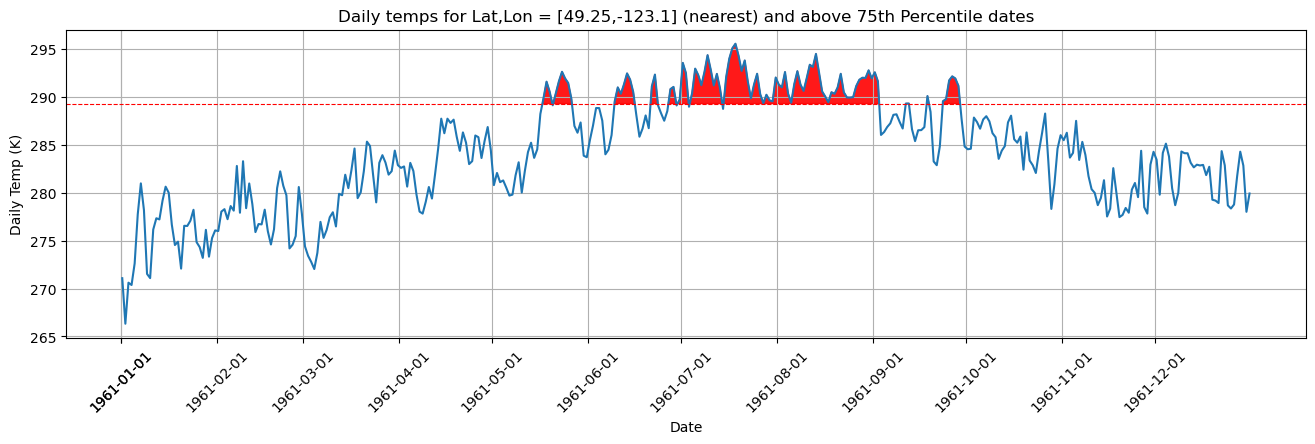

In [20]:
# plot for specific grid cell and the 75th percentile
plot_data = ds.tas.sel(lat=49.25,lon=-123.1, method="nearest") # Vancouver 49.246292, -123.116226
plot_c_75 = c_75.sel(lat=49.25,lon=-123.1, method="nearest")
plt.figure(figsize=(16,4))
plt.plot(plot_data.time, plot_data.data)
plt.fill_between(  # plot with color in between
    plot_data.time,  # x values
    # top boundary - y values above 0.5
    plot_data.data,
    plot_c_75,  # bottom boundary - 0.5
    where=(plot_data >= plot_c_75),
    color="red",  # color
    alpha=0.9,  # transparency value
    interpolate=True
)
plt.axhline(plot_c_75, color="red", linewidth=0.8, linestyle="dashed")
plt.tick_params(axis='x',rotation=45)
plt.xticks(["1961-01","1961-02","1961-03","1961-04","1961-05","1961-06",
           "1961-07","1961-08","1961-09","1961-10","1961-11","1961-12","1961-01"])
plt.grid()
#plt.ylim([280,315])
plt.title("Daily temps for Lat,Lon = [49.25,-123.1] (nearest) and above 75th Percentile dates")
plt.xlabel("Date")
plt.ylabel("Daily Temp (K)")


In [127]:
#plot_data
plot_c_75

<xarray.DataArray 't2m' ()> Size: 8B
array(286.74971771)
Coordinates:
    lat       float64 8B 49.25
    lon       float64 8B -123.0
    quantile  float64 8B 0.75

In [21]:
plot_data.time.dt.dayofyear

<xarray.DataArray 'dayofyear' (time: 365)> Size: 3kB
array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
       105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
       118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130,
       131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143,
       144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156,
       157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169,
       170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182,
       183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195,
       196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208,
       209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221,
       222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234,
       235, 236, 237, 238, 239, 240, 241, 242, 243, 244, 245, 246, 247,
       248, 249, 250, 251, 252, 253, 254, 255, 256, 257, 258, 259, 260,
       261, 262, 263, 264, 265, 266, 267, 268, 269, 270, 271, 272, 273,
       274, 275, 276, 277, 278, 279, 280, 281, 282, 283, 284, 285, 286,
       287, 288, 289, 290, 291, 292, 293, 294, 295, 296, 297, 298, 299,
       300, 301, 302, 303, 304, 305, 306, 307, 308, 309, 310, 311, 312,
       313, 314, 315, 316, 317, 318, 319, 320, 321, 322, 323, 324, 325,
       326, 327, 328, 329, 330, 331, 332, 333, 334, 335, 336, 337, 338,
       339, 340, 341, 342, 343, 344, 345, 346, 347, 348, 349, 350, 351,
       352, 353, 354, 355, 356, 357, 358, 359, 360, 361, 362, 363, 364,
       365])
Coordinates:
  * time     (time) datetime64[ns] 3kB 1961-01-01T12:00:00 ... 1961-12-31T12:...
    lat      float64 8B 48.84
    lon      float64 8B 0.0
    height   float64 8B 2.0

In [22]:
x1 = plot_data.time.dt.dayofyear.values
y1 = plot_data.values
#x1, y1
coefs = np.polyfit(x1, y1, 3)
poly = np.poly1d(coefs)

# other helpful guide at https://data36.com/polynomial-regression-python-scikit-learn/

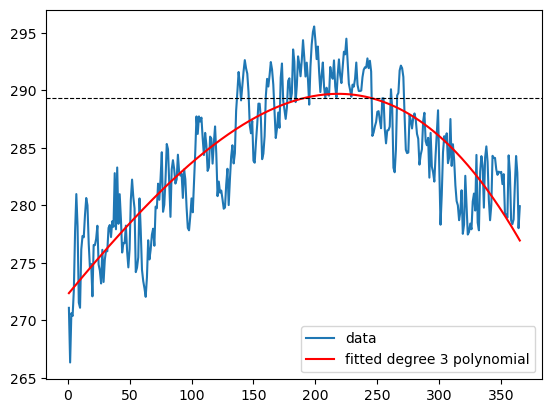

In [23]:
x_values = np.linspace(min(x1), max(x1), 366) # create some x values for plotting polynomial fit
plt.plot(x1,y1, label='data')
plt.plot(x_values, poly(x_values), label='fitted degree 3 polynomial', color='red')
plt.axhline(plot_c_75, color="black", linewidth=0.8, linestyle="dashed") 
plt.legend()


#### find summer length and also which days to add to figure


In [24]:
summer_length = np.count_nonzero(poly(x_values) >= plot_c_75.values)
summer_length

np.int64(56)

In [25]:
summer_days = np.where(poly(x_values) >= plot_c_75.values)[0]
summer_days

array([190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202,
       203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215,
       216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228,
       229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 241,
       242, 243, 244, 245])

In [27]:
first_day = min(summer_days)
last_day = max(summer_days)
first_day, last_day

(np.int64(190), np.int64(245))

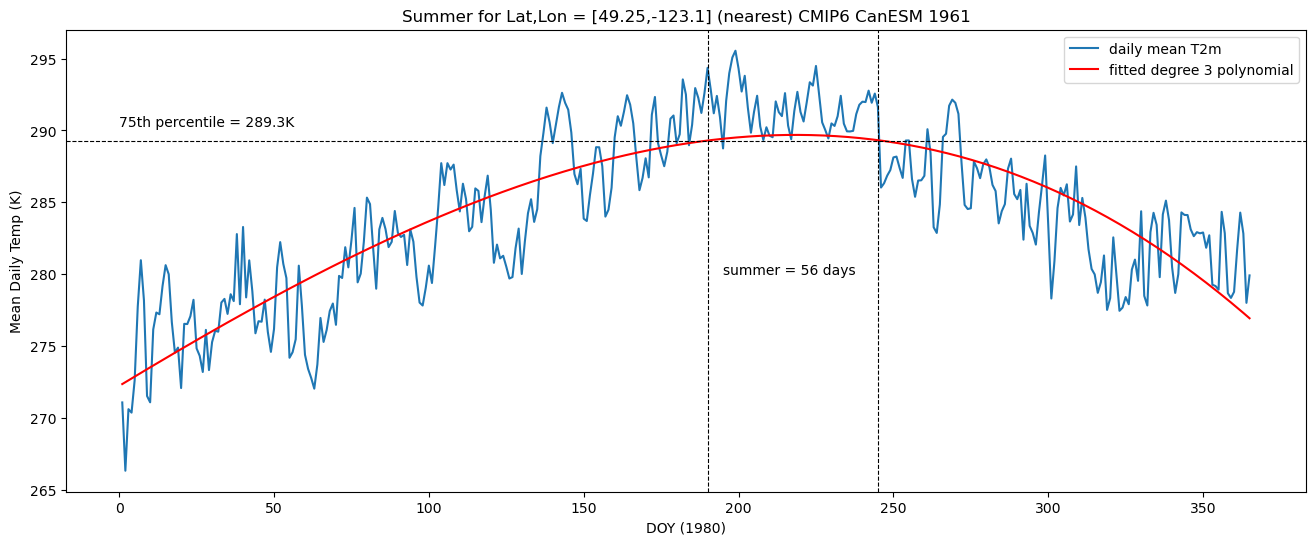

In [28]:
# make a new plot
x_values = np.linspace(min(x1), max(x1), 366) # create some x values for plotting polynomial fit
plt.figure(figsize=(16,6))
plt.plot(x1,y1, label='daily mean T2m')
plt.plot(x_values, poly(x_values), label='fitted degree 3 polynomial', color='red')
plt.axhline(plot_c_75.values, color="black", linewidth=0.8, linestyle="dashed") 
plt.axvline(first_day, color="black", linewidth=0.8, linestyle="dashed")
plt.axvline(last_day, color="black", linewidth=0.8, linestyle="dashed")
plt.annotate('summer = '+str(summer_length)+' days', xy=(first_day+5,280))
plt.annotate('75th percentile = '+str(np.round(plot_c_75.values,1))+'K', xy=(0,plot_c_75.values+1))
plt.xlabel('DOY (1980)')
plt.ylabel('Mean Daily Temp (K)')
plt.title("Summer for Lat,Lon = [49.25,-123.1] (nearest) CMIP6 CanESM 1961")
plt.legend()


## Not terrible, but of course polynomial fit is not the way to go. This data from CanESM is a very coarse resolution

# try the data from GFDL-ESM4, which has finer resolution

In [39]:
# five years of data
file_path = '../../../Data/CMIP6/GFDL-ESM4/tas_day_GFDL-ESM4_historical_r1i1p1f1_gr1_19900101-19941231.nc'

ds_gfdl = xr.open_mfdataset(file_path)#, chunks={'latitude': 10, 'longitude': 10})

In [40]:
ds_gfdl

<xarray.Dataset> Size: 378MB
Dimensions:    (lat: 180, bnds: 2, lon: 288, time: 1825)
Coordinates:
  * lat        (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * bnds       (bnds) float64 16B 1.0 2.0
  * lon        (lon) float64 2kB 0.625 1.875 3.125 4.375 ... 356.9 358.1 359.4
  * time       (time) object 15kB 1990-01-01 12:00:00 ... 1994-12-31 12:00:00
    height     float64 8B ...
Data variables:
    lat_bnds   (lat, bnds) float64 3kB dask.array<chunksize=(180, 2), meta=np.ndarray>
    lon_bnds   (lon, bnds) float64 5kB dask.array<chunksize=(288, 2), meta=np.ndarray>
    tas        (time, lat, lon) float32 378MB dask.array<chunksize=(1, 180, 288), meta=np.ndarray>
    time_bnds  (time, bnds) object 29kB dask.array<chunksize=(1, 2), meta=np.ndarray>
Attributes: (12/46)
    external_variables:     areacella
    history:                File was processed by fremetar (GFDL analog of CM...
    table_id:               day
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    ...                     ...
    title:                  NOAA GFDL GFDL-ESM4 model output prepared for CMI...
    tracking_id:            hdl:21.14100/ef0a0372-2d5b-4290-89a9-83c849cfa64e
    variable_id:            tas
    variant_info:           N/A
    references:             see further_info_url attribute
    variant_label:          r1i1p1f1

In [41]:
ds_gfdl['time'] = ds_gfdl.indexes['time'].to_datetimeindex()

In [42]:
ds_gfdl.time

<xarray.DataArray 'time' (time: 1825)> Size: 15kB
array(['1990-01-01T12:00:00.000000000', '1990-01-02T12:00:00.000000000',
       '1990-01-03T12:00:00.000000000', ..., '1994-12-29T12:00:00.000000000',
       '1994-12-30T12:00:00.000000000', '1994-12-31T12:00:00.000000000'],
      shape=(1825,), dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 15kB 1990-01-01T12:00:00 ... 1994-12-31T12...
    height   float64 8B ...

### generate weights by latitude

In [43]:
weights = np.cos(np.deg2rad(ds_gfdl.lat))
weights.name = "weights" # not sure why we did this since we aren't merging with the dataset but OK

# get weighted spatial mean
ds_gfdl_tas_gm = ds_gfdl.tas.weighted(weights).mean(["lon","lat"])
ds_gfdl_tas_gm

<xarray.DataArray 'tas' (time: 1825)> Size: 15kB
dask.array<truediv, shape=(1825,), dtype=float64, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 15kB 1990-01-01T12:00:00 ... 1994-12-31T12...
    height   float64 8B 2.0

### plot time series

Text(0.5, 1.0, '')

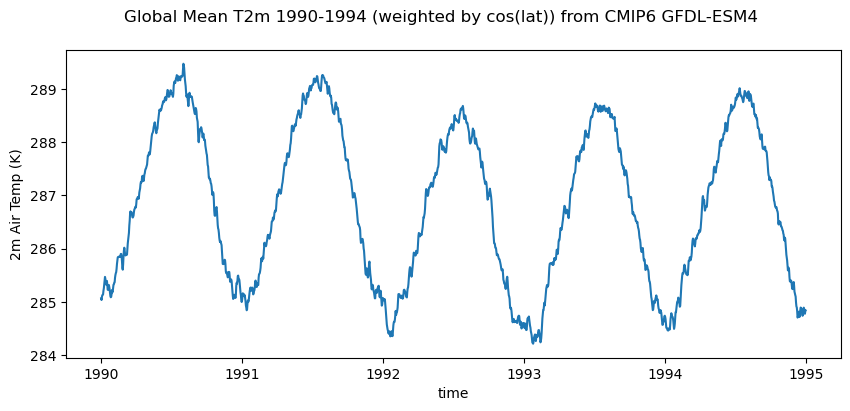

In [44]:
# plot the time series
fig,ax = plt.subplots(1,1, figsize=(10,4))
ds_gfdl_tas_gm.plot()
ax.set_ylabel("2m Air Temp (K)")
#ax.xaxis.set_tick_params(rotation=45)
plt.suptitle("Global Mean T2m 1990-1994 (weighted by cos(lat)) from CMIP6 GFDL-ESM4")
plt.title("")

### N. America map of 5 year mean temp

Text(0.5, 1.0, '\nMean Temp 1990-1994 from GFDL-ESM4 Hist')

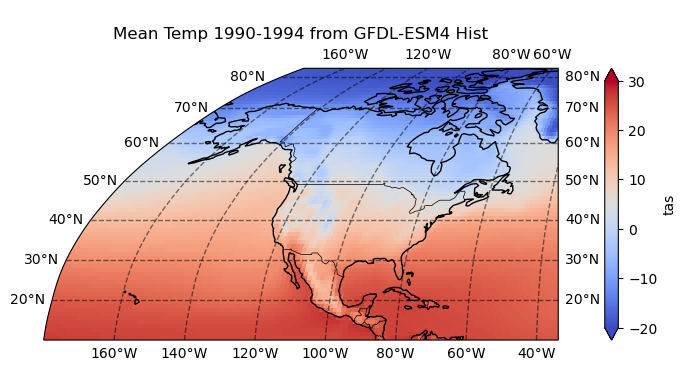

In [45]:
# create blank fig
fig = plt.figure(figsize = (12,12))

# Baseline
ax1 = fig.add_subplot(3,1,1,projection=ccrs.Robinson(central_longitude=0))

# add coastlines and grid
ax1.coastlines()
ax1.gridlines(draw_labels=True, linewidth=1, color='black', alpha=0.5, linestyle='--')

# plot data and exclude tropics
(ds_gfdl.tas.mean(["time"])+KtoC).plot(
    ax=ax1,
    transform=ccrs.PlateCarree(), 
    vmin=-20,
    vmax=30, 
    cmap="coolwarm"#"YlOrRd"#cmap="coolwarm"
)

ax1.set_extent((-180, -50, 10, 75))
ax1.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='black')
ax1.set_title("\nMean Temp 1990-1994 from GFDL-ESM4 Hist")

### PNW map

Text(0.5, 1.0, '\nMean Temp 1990-1994 from GFDL-ESM4 Hist')

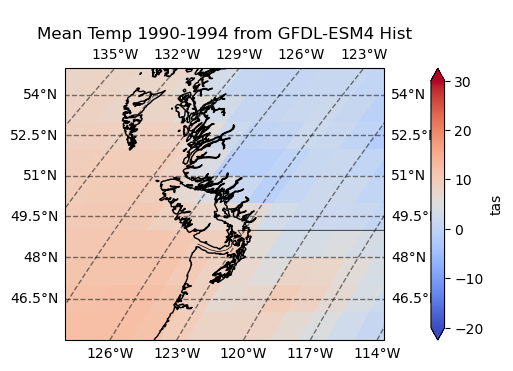

In [47]:
# create blank fig
fig = plt.figure(figsize = (12,12))

# Baseline
ax1 = fig.add_subplot(3,1,1,projection=ccrs.Robinson(central_longitude=0))

# add coastlines and grid
ax1.coastlines()
ax1.gridlines(draw_labels=True, linewidth=1, color='black', alpha=0.5, linestyle='--')

# plot data and exclude tropics
(ds_gfdl.tas.mean(["time"])+KtoC).plot(
    ax=ax1,
    transform=ccrs.PlateCarree(), 
    vmin=-20,
    vmax=30, 
    cmap="coolwarm"#"YlOrRd"#cmap="coolwarm"
)

ax1.set_extent((-128, -122, 45, 55))
ax1.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='black')
ax1.set_title("\nMean Temp 1990-1994 from GFDL-ESM4 Hist")

### 75th percentile of 1990-1994

In [49]:
%%time
#c_75 = ds.t2m.where(ds.t2m != 0).quantile(0.75, dim=('time'))
c_75_gfdl = ds_gfdl.tas.quantile(0.75, dim=('time'))
c_75_gfdl

CPU times: user 62.8 ms, sys: 29.5 ms, total: 92.3 ms
Wall time: 95.5 ms


<xarray.DataArray 'tas' (lat: 180, lon: 288)> Size: 415kB
dask.array<getitem, shape=(180, 288), dtype=float64, chunksize=(107, 171), chunktype=numpy.ndarray>
Coordinates:
  * lat       (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon       (lon) float64 2kB 0.625 1.875 3.125 4.375 ... 356.9 358.1 359.4
    quantile  float64 8B 0.75

CPU times: user 28.6 s, sys: 2.98 s, total: 31.6 s
Wall time: 25.1 s


Text(0, 0.5, 'Daily Temp ($^{\\circ} C$)')

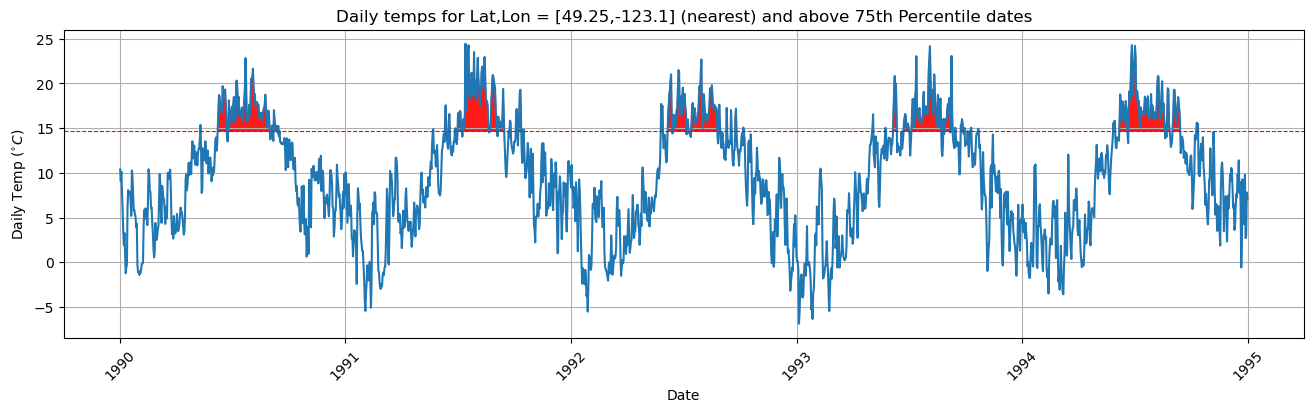

In [54]:
%%time
# plot for specific grid cell and the 75th percentile
plot_data = ds_gfdl.tas.sel(lat=49.25,lon=-123.1, method="nearest") # Vancouver 49.246292, -123.116226
plot_c_75 = c_75_gfdl.sel(lat=49.25,lon=-123.1, method="nearest")
plot_data = plot_data + KtoC
plot_c_75 = plot_c_75 + KtoC
plt.figure(figsize=(16,4))
plt.plot(plot_data.time, plot_data.data)
plt.fill_between(  # plot with color in between
    plot_data.time,  # x values
    # top boundary - y values above 0.5
    plot_data.data,
    plot_c_75,  # bottom boundary - 0.5
    where=(plot_data >= plot_c_75),
    color="red",  # color
    alpha=0.9,  # transparency value
    interpolate=True
)
plt.axhline(plot_c_75, color="red", linewidth=0.8, linestyle="dashed")
plt.tick_params(axis='x',rotation=45)
#plt.xticks(["1961-01","1961-02","1961-03","1961-04","1961-05","1961-06",
#           "1961-07","1961-08","1961-09","1961-10","1961-11","1961-12","1961-01"])
plt.grid()
#plt.ylim([280,315])
plt.title("Daily temps for Lat,Lon = [49.25,-123.1] (nearest) and above 75th Percentile dates")
plt.xlabel("Date")
plt.ylabel("Daily Temp ($^{\circ} C$)")